## EDA датасета по запросам и объявлениям

In [1]:
import numpy as np
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

Все исходные .parquet с данными должны лежать в /data

In [2]:
ROOT = Path.cwd().resolve().parent
DATA_PATH = ROOT / "data"

Загрузка данных в датафрейм и 5 рандомных запросов:

In [4]:
df = pl.read_parquet(DATA_PATH / "train.parquet")
print(f"Размер датафрейма: {df.shape}")
df.sample(10)

Размер датафрейма: (497673, 19)


search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
str,i64,i32,str,i64,str,f64,f64,"decimal[27,15]",i64,"decimal[18,15]",i64,"decimal[17,15]",bool,bool,str,str,str,i64
"""замена герметика в ванне""",623130,0,"""Вид услуги Ремонт и отделка""",114,"""Сантехник. Услуги сантехника. …",31.0,4.741935,350.000000000000000,44730,48.085442999999998,623130,46.365794000000001,false,false,"""Вид услуги Ремонт и отделка Ти…","""3f77fb41ce73722d""","""👍 Решим все ваши проблемы с са…",114
"""аренда фаркопа""",646600,0,"""Аренда авто Авто для личного и…",114,"""4х4 нива. Аренда внедорожника""",41.0,5.0,4000.000000000000000,1289817,55.883216042999209,646600,54.781435050383251,false,false,"""Вид услуги Автосервис, аренда …","""23f670fab3702b73""","""🔥 Арендa лeгендаpной ЛАДА НИBА…",114
"""ремонт посудомоечных машин""",637640,0,"""Тип услуги Посудомоечные машин…",114,"""Ремонт Посудомоечных Машин, по…",0.0,null,450.000000000000000,2169974,37.729621217773442,637640,55.620879622315776,false,false,"""Вид услуги Ремонт и обслуживан…","""420309e62b98832b""","""👋 Привет! Я Глеб частный маст…",114
"""остекление балконов евробалкон""",630090,0,"""""",114,"""Остекление балконов""",104.0,5.0,1.000000000000000,44728,20.507788000000001,630090,54.709364999999998,false,false,"""Вид услуги Ремонт и отделка Ти…","""e13567d2ebbe86d7""","""Качественно и в срок выполним …",114
"""печать наклеек""",662210,0,"""""",114,"""Печать наклеек, стикеры, этике…",21.0,5.0,1.000000000000000,2302479,47.311321565496108,662210,56.129156027234352,false,false,"""Вид услуги Место оказания услу…","""d8caff08f14e31f0""","""Профессиональные наклейки под …",114
"""ремонт телевизоров""",653241,0,"""Вид услуги Ремонт и обслуживан…",114,"""Ремонт телевизоров и мониторов""",20.0,5.0,300.000000000000000,84438,45.957828350106709,653241,51.501909680468323,false,false,"""Вид услуги Ремонт и обслуживан…","""184bbc8be930dadb""","""Производим качественный ремонт…",114
"""вывоз мусора""",107621,0,"""Кто оказывает услуги Частный и…",114,"""Демонтажные работы и вывоз мус…",0.0,0.0,10000.000000000000000,2058735,30.243096000000001,653240,59.987501000000002,false,false,"""Вид услуги Строительство Место…","""35ee0551b6b0a2a5""","""Здравствуйте, Мы русская бри…",114
"""отделочные работы""",628810,0,"""Вид услуги Ремонт и отделка""",114,"""Отделочные работы""",18.0,4.166667,200.000000000000000,1287645,103.891547891627994,628810,52.529213679444702,false,false,"""Вид услуги Ремонт и отделка Ти…","""e864e22e057d3dcb""","""Меня зовут Светлана (русская) …",114
"""получение медицинской лицензии""",640860,0,"""""",114,"""Медицинская лицензия""",0.0,0.0,10000.000000000000000,4145,44.003096712963739,640860,56.328153646126474,false,false,"""Вид услуги Деловые услуги Тип …","""cfe3bd871fbcb7e0""","""Лицензирование медицинской дея…",114


Проверка, есть ли пропуски или строки-повторы:

In [5]:
info = "\n".join([f"{col}: {df[col].null_count()}" for col in df.columns])
print(f"Пропущенные значения по столбцам: {info}")
print()
print(f"Количество записей-дубликатов: {df.is_duplicated().sum()}")

Пропущенные значения по столбцам: search_query: 0
search_location_id: 0
search_is_delivery_search: 0
search_infm_params_text: 0
search_category: 0
item_title_raw: 0
item_rating_reviews_count: 19211
item_rating: 28232
item_price: 0
item_microcat_id: 0
item_longitude: 4
item_location_id: 0
item_latitude: 4
item_is_phone_hidden: 0
item_is_message_forbidden: 0
item_infm_params_text: 0
item_id: 0
item_description_raw: 0
item_category_id: 0

Количество записей-дубликатов: 48533


Пример повтора:

In [6]:
df.filter(df.is_duplicated()
          & (pl.col("search_query") == "перенос розеток"))

search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
str,i64,i32,str,i64,str,f64,f64,"decimal[27,15]",i64,"decimal[18,15]",i64,"decimal[17,15]",bool,bool,str,str,str,i64
"""перенос розеток""",654070,0,"""Тип услуги Электрика Вид услуг…",114,"""Электрик. Перенос проводки в к…",250.0,4.936,500.000000000000000,44731,60.594963452362052,654070,56.841868469943371,false,false,"""Вид услуги Ремонт и отделка Ти…","""0d52f33db0d94329""","""Электрик. Перенос проводки в к…",114
"""перенос розеток""",654070,0,"""Тип услуги Электрика Вид услуг…",114,"""Электрик. Перенос проводки в к…",250.0,4.936,500.000000000000000,44731,60.594963452362052,654070,56.841868469943371,false,false,"""Вид услуги Ремонт и отделка Ти…","""0d52f33db0d94329""","""Электрик. Перенос проводки в к…",114


### Числовые признаки:

shape: (1, 3)
┌──────────────┬──────────────────┬──────────────────┐
│ search_query ┆ item_category_id ┆ item_microcat_id │
│ ---          ┆ ---              ┆ ---              │
│ u32          ┆ u32              ┆ u32              │
╞══════════════╪══════════════════╪══════════════════╡
│ 74529        ┆ 8                ┆ 212              │
└──────────────┴──────────────────┴──────────────────┘


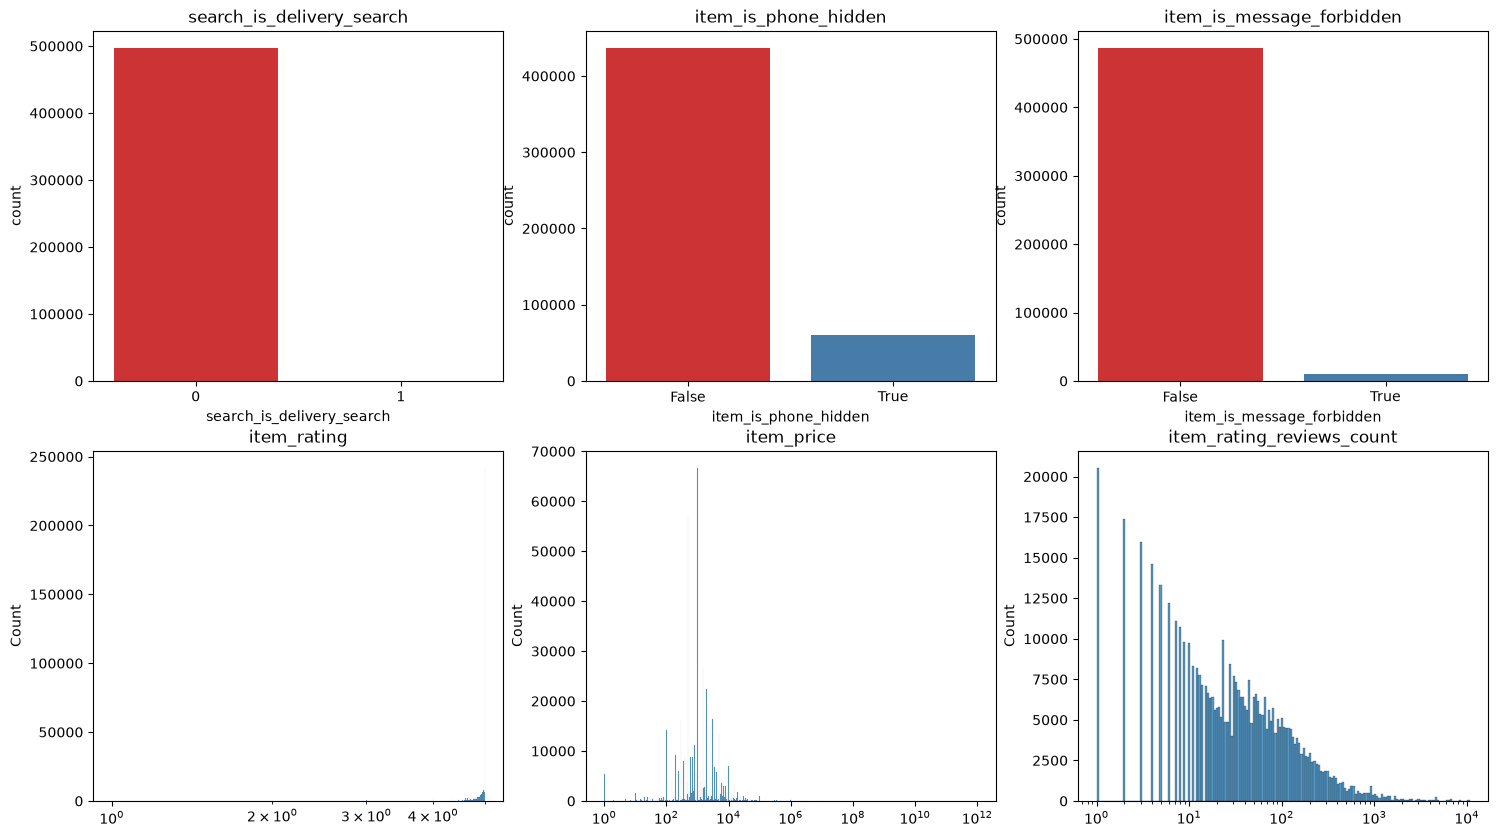

In [7]:
df_deduplicated = df.unique()

print(df_deduplicated.select([
    pl.col("search_query").n_unique(),
    pl.col("item_category_id").n_unique(),
    pl.col("item_microcat_id").n_unique(),
]))

bool_cols = ["search_is_delivery_search", "item_is_phone_hidden", "item_is_message_forbidden"]
continous_cols = ["item_rating", "item_price", "item_rating_reviews_count"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i in range(3):
    axes[0, i].set_title(str(bool_cols[i]))
    sns.countplot(x=df[bool_cols[i]], hue=df[bool_cols[i]], legend=False, ax=axes[0, i], palette="Set1")

    axes[1, i].set_title(str(continous_cols[i]))
    sns.histplot(df[continous_cols[i]].to_numpy(), ax=axes[1, i], log_scale=True)


Судя по гистограммам, в данных цен, указанных в объявлении есть выбросы:

In [8]:
df_deduplicated.select(continous_cols).describe()

statistic,item_rating,item_price,item_rating_reviews_count
str,f64,f64,f64
"""count""",440667.0,467054.0,449292.0
"""null_count""",26387.0,0.0,17762.0
"""mean""",4.816078,1.8669e7,87.07352
"""std""",0.656979,3.6678e9,311.265396
"""min""",0.0,-1.0,0.0
"""25%""",4.880597,399.0,8.0
"""50%""",5.0,1000.0,25.0
"""75%""",5.0,2000.0,70.0
"""max""",5.0,1.0000e12,10678.0


### Тексты запросов и объявлений:

In [9]:
text_cols = ["search_query", "search_infm_params_text", "item_title_raw", "item_description_raw", "item_infm_params_text"]

texts_describe = {
    "column": [],
    "min_len": [],
    "max_len": [],
    "min_value": []
}

for col in text_cols:
    texts_describe["column"].append(col)
    min_len = df_deduplicated[col].str.len_chars().min()
    texts_describe["min_len"].append(min_len)
    texts_describe["max_len"].append(df_deduplicated[col].str.len_chars().max())
    texts_describe["min_value"].append(df_deduplicated.filter(pl.col(col).str.len_chars() == min_len)[col][0])

pl.DataFrame(texts_describe)


column,min_len,max_len,min_value
str,i64,i64,str
"""search_query""",1,113,"""ё"""
"""search_infm_params_text""",0,1079,""""""
"""item_title_raw""",1,100,"""Р"""
"""item_description_raw""",1,8494,"""И"""
"""item_infm_params_text""",10,11899,"""Вид услуги"""


Попробуем найти все фильтры поиска, чтобы удалить их из параметров запроса.

Для каждой категории найдем `item_infm_params_text` с наибольшим кол-вом слов. Скорее всего, там будет выбрано больше всего разных фильтров

In [10]:

max_spaces = (
    df
    .with_columns(pl.col("item_infm_params_text").fill_null(""))
    
    .with_columns(pl.col("item_infm_params_text").str.count_matches(" ").alias("space_count"))
    
    .filter(pl.col("space_count") == pl.col("space_count").max().over("search_category"))
    
    .select(["search_category", "item_infm_params_text"])
    
    .unique(subset=["search_category"])
)

max_spaces

search_category,item_infm_params_text
i64,str
81,"""Вид услуги Автосервис, аренда …"
114,"""Вид услуги Автосервис, аренда …"
10,"""Вид услуги Автосервис, аренда …"
0,"""Вид услуги Красота, здоровье М…"


In [12]:
for cat in max_spaces["search_category"]:
    print(max_spaces.filter(pl.col("search_category") == cat)["item_infm_params_text"][0])

Вид услуги Автосервис, аренда Тип услуги Аренда спецтехники Место оказания услуг Московская область, городской округ Ступино Марка Kubota Модель KH191 Тип техники Мини-экскаватор Доставка Начальная цена Минимальное время аренды 3 Техника Землеройная техника Тип землеройной техники Мини-экскаватор Глубина копания 3.2 Дополнительное оборудование Дополнительное оборудование Планировочный ковш Дополнительное оборудование Дополнительное оборудование С оператором Да Тип стоимости за смену Способ размещения Classified
Вид услуги Автосервис, аренда Тип услуги Автосервис Место оказания услуг Томск, проезд Вершинина, 5 Гарантия Опыт работы 10 Дополнительно Тёплый бокс Тип стоимости за услугу Начальная цена Время для связи от 28800 Время для связи до 72000 Время для связи, дни недели пн. Время для связи, дни недели вт. Время для связи, дни недели ср. Время для связи, дни недели чт. Время для связи, дни недели пт. Время для связи, дни недели сб. Время для связи, дни недели вс. График работы от 288